# Tugas - Medical Cost Prediction

| Nama | NRP |
|------|-----|
| Malfino Muhammad Willianz | 5054251028 |

## Deskripsi Tugas

Pada tugas ini, kita akan menggunakan Medical Cost Personal Dataset dari Kaggle.

Dataset:
- https://www.kaggle.com/mirichoi0218/insurance

Target yang diprediksi adalah `charges`.

Model yang digunakan:
1. Linear Regression
2. Polynomial Regression
3. Ridge Regression
4. Lasso Regression
5. Decision Tree Regressor
6. Support Vector Regression


# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('insurance.csv')

print('Shape:', df.shape)

Shape: (1338, 7)


In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


Dataset terdiri dari 1338 baris dan 7 kolom: 3 fitur numerik (`age`, `bmi`, `children`), 3 fitur kategorikal (`sex`, `smoker`, `region`), dan target `charges` (numerik kontinu).

In [5]:
print('Jumlah missing value per kolom:')
print(df.isna().sum())
print()
print('Jumlah baris duplikat:', df.duplicated().sum())
print(df[df.duplicated(keep=False)])

Jumlah missing value per kolom:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Jumlah baris duplikat: 1
     age   sex    bmi  children smoker     region    charges
195   19  male  30.59         0     no  northwest  1639.5631
581   19  male  30.59         0     no  northwest  1639.5631


Tidak ada missing value pada seluruh kolom, tetapi terdapat **1 baris duplikat** (index 195 dan 581, identik di semua kolom termasuk `charges`). Baris duplikat ini akan dibuang pada tahap preprocessing.

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


Skala fitur numerik berbeda cukup jauh: `age` berkisar 18–64, `bmi` 15,96–53,13, dan `children` hanya 0–5. Target `charges` memiliki rentang yang sangat lebar (1.121,87 s.d. 63.770,43) dengan mean (13.270,42) jauh di atas median (9.382,03), menandakan distribusi yang **right-skewed**.

In [7]:
for col in ['sex', 'smoker', 'region']:
    print(df[col].value_counts())
    print()

sex
male      676
female    662
Name: count, dtype: int64

smoker
no     1064
yes     274
Name: count, dtype: int64

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64



`sex` dan `region` cukup seimbang, sedangkan `smoker` **imbalanced**: hanya 274 perokok (20,48%) dibanding 1064 non-perokok.

## Lakukan Exploratory Data Analysis (EDA) sederhana yang diperlukan.


## Target

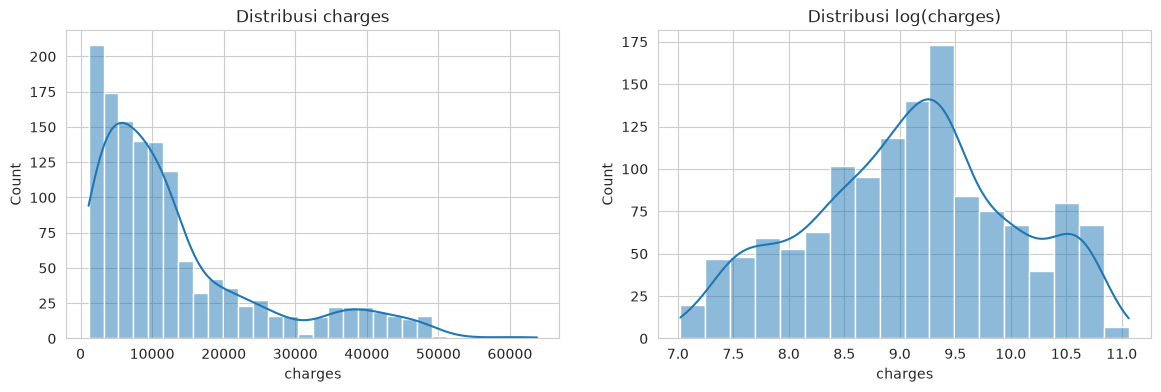

Skewness charges: 1.5158796580240388


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['charges'], kde=True, ax=axes[0])
axes[0].set_title('Distribusi charges')
sns.histplot(np.log(df['charges']), kde=True, ax=axes[1])
axes[1].set_title('Distribusi log(charges)')
plt.show()

print('Skewness charges:', df['charges'].skew())

Distribusi `charges` sangat miring ke kanan (skewness ≈ 1,52) dan terlihat multimodal. Setelah transformasi log distribusinya lebih simetris, namun tetap ada beberapa puncak yang mengindikasikan adanya kelompok pasien dengan pola biaya berbeda.

## Fitur Kategorikal vs Charges

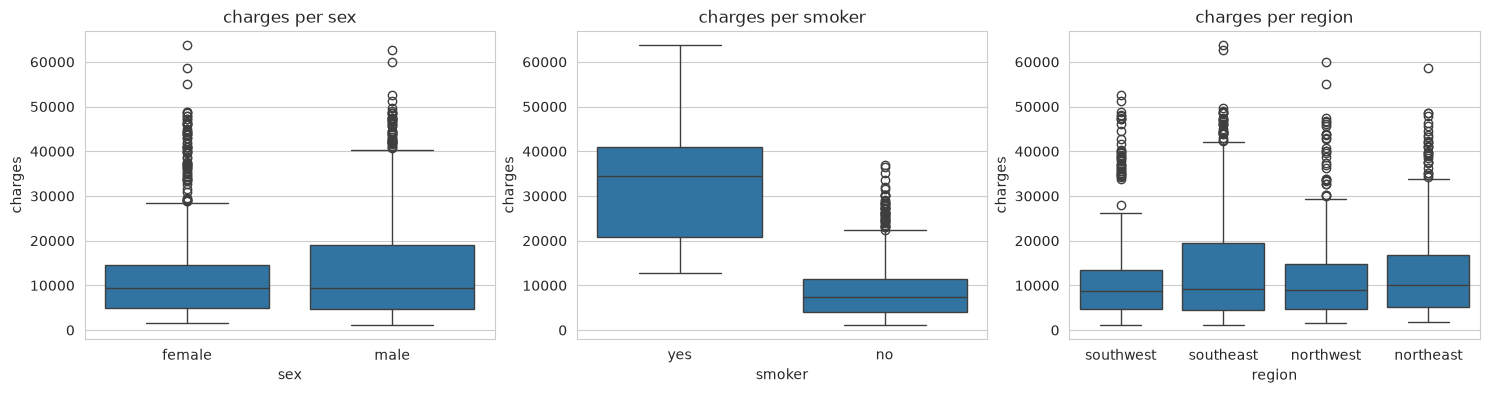

,mean,median,count
smoker,,,
no,8434.268298,7345.40530,1064
yes,32050.231832,34456.34845,274


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, ['sex', 'smoker', 'region']):
    sns.boxplot(data=df, x=col, y='charges', ax=ax)
    ax.set_title(f'charges per {col}')
plt.show()

df.groupby('smoker')['charges'].agg(['mean', 'median', 'count'])

`smoker` adalah fitur yang paling membedakan `charges`: rata-rata biaya perokok **32.050,23** vs non-perokok **8.434,27** (hampir 4 kali lipat). Sebaliknya, `sex` dan `region` hanya memberikan perbedaan kecil (region southeast sedikit lebih tinggi).

## Fitur Numerik vs Charges

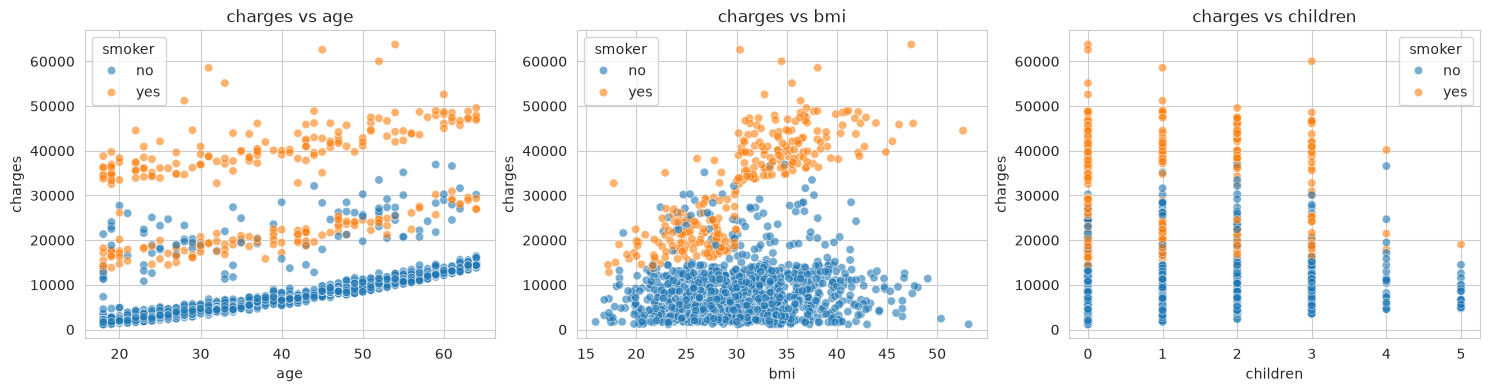

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, ['age', 'bmi', 'children']):
    sns.scatterplot(data=df, x=col, y='charges', hue='smoker', hue_order=['no', 'yes'], ax=ax, alpha=0.6)
    ax.set_title(f'charges vs {col}')
plt.show()

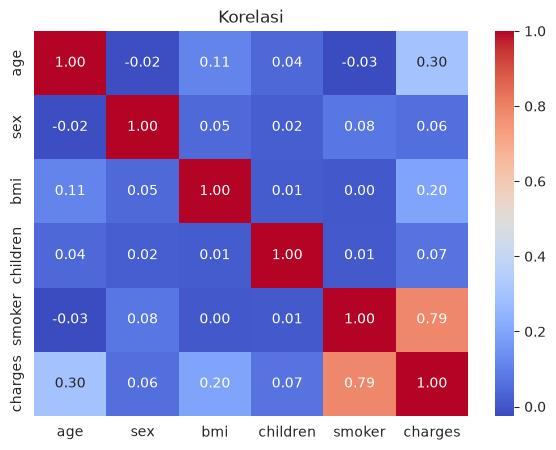

In [11]:
df_corr = df.copy()
df_corr['smoker'] = (df_corr['smoker'] == 'yes').astype(int)
df_corr['sex'] = (df_corr['sex'] == 'male').astype(int)

plt.figure(figsize=(7, 5))
sns.heatmap(df_corr.drop(columns='region').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi')
plt.show()

Scatter plot memperlihatkan pola yang menarik:

- **`age` vs `charges`:** terbentuk 3 "pita" yang sejajar. Biaya naik secara linear terhadap usia, namun level dasarnya ditentukan oleh status merokok.
- **`bmi` vs `charges`:** untuk non-perokok BMI hampir tidak berpengaruh, sedangkan untuk perokok terjadi lonjakan biaya yang tajam saat BMI > 30 (obesitas). Ini merupakan **efek interaksi** `bmi × smoker` yang tidak dapat ditangkap oleh model linear biasa.
- **`children`:** hampir tidak berkorelasi dengan `charges`.

Heatmap korelasi mengonfirmasi `smoker` (0,79) sebagai fitur terkuat, diikuti `age` (0,30) dan `bmi` (0,20). Korelasi antar fitur sendiri rendah, sehingga tidak ada masalah multikolinearitas yang berarti.

# 2. Preprocessing

Pisahkan fitur numerik dan kategorikal. Gunakan OneHotEncoder untuk fitur kategorikal.

Model Linear Regression, Polynomial Regression, Ridge, Lasso, dan SVR menggunakan data yang telah di-scaling. Decision Tree Regressor tidak memerlukan scaling.


In [12]:
df = df.drop_duplicates().reset_index(drop=True)

X = df.drop(columns='charges')
y = df['charges']

print('Shape X:', X.shape)
print('Shape y:', y.shape)

Shape X: (1337, 6)
Shape y: (1337,)


In [13]:
num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Train:', X_train.shape)
print('Test :', X_test.shape)

Train: (1069, 6)
Test : (268, 6)


In [15]:
# Untuk model linear dan SVR: fitur numerik di-scaling, kategorikal di-OneHotEncode (drop='first' untuk menghindari dummy variable trap).
preprocess_scaled = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols),
])

# Untuk Decision Tree: tanpa scaling, cukup OneHotEncode.
preprocess_tree = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols),
])

cv = KFold(n_splits=5, shuffle=True, random_state=42)

preprocess_scaled.fit(X_train)
print('Fitur setelah preprocessing:', list(preprocess_scaled.get_feature_names_out()))

Fitur setelah preprocessing: ['num__age', 'num__bmi', 'num__children', 'cat__sex_male', 'cat__smoker_yes', 'cat__region_northwest', 'cat__region_southeast', 'cat__region_southwest']


# 3. Eksperimen Model

## 3.1 Linear Regression

Bangun model Linear Regression menggunakan data hasil preprocessing.


In [16]:
lin_reg = Pipeline([
    ('prep', preprocess_scaled),
    ('model', LinearRegression()),
])
lin_reg.fit(X_train, y_train)

coef = pd.Series(lin_reg.named_steps['model'].coef_, index=preprocess_scaled.get_feature_names_out())
coef.sort_values()

cat__region_southeast     -838.919616
cat__region_southwest     -659.139752
cat__region_northwest     -391.761455
cat__sex_male             -101.542054
num__children              636.501185
num__bmi                  1927.828251
num__age                  3472.975553
cat__smoker_yes          23077.764593
dtype: float64

Karena fitur numerik sudah di-scaling, koefisien dapat dibandingkan secara langsung. Status perokok menambah biaya sekitar **23.077** sedangkan kenaikan 1 standar deviasi usia menambah sekitar 3.473. Koefisien `sex` dan `region` relatif kecil.

In [17]:
lin_predictions = lin_reg.predict(X_test)

## 3.2 Polynomial Regression

Gunakan PolynomialFeatures. Tentukan degree berdasarkan eksperimen.


In [18]:
degree_results = []
for d in [1, 2, 3, 4]:
    model = Pipeline([
        ('prep', preprocess_scaled),
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('model', LinearRegression()),
    ])
    model.fit(X_train, y_train)
    degree_results.append({
        'degree': d,
        'Jumlah Fitur': model.named_steps['poly'].n_output_features_,
        'Train R2': r2_score(y_train, model.predict(X_train)),
        'Test R2': r2_score(y_test, model.predict(X_test)),
    })

pd.DataFrame(degree_results).set_index('degree')

,Jumlah Fitur,Train R2,Test R2
degree,,,
1,8,0.729906,0.806929
2,44,0.834026,0.882530
3,164,0.847116,0.870918
4,494,0.866558,0.800291


Degree 2 memberikan Test R² tertinggi (0,8825), karena fitur interaksi seperti `bmi × smoker_yes` dan `age²` mulai terbentuk. Pada degree 3 dan 4 jumlah fitur melonjak (164 dan 494) dan Test R² justru turun ke 0,8003 meskipun Train R² terus naik, yang merupakan gejala **overfitting**. Oleh karena itu dipilih **degree = 2**.

In [19]:
poly_reg = Pipeline([
    ('prep', preprocess_scaled),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', LinearRegression()),
])
poly_reg.fit(X_train, y_train)

poly_predictions = poly_reg.predict(X_test)

## 3.3 Ridge Regression

Gunakan Ridge Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [20]:
# Ridge dipasang di atas fitur polynomial degree 2 agar regularisasi punya efek berarti.
ridge_pipe = Pipeline([
    ('prep', preprocess_scaled),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', Ridge()),
])

ridge_grid = GridSearchCV(ridge_pipe, {'model__alpha': [0.01, 0.1, 1, 10, 100, 1000]},
                          cv=cv, scoring='neg_root_mean_squared_error', return_train_score=True)
ridge_grid.fit(X_train, y_train)

print('Best alpha:', ridge_grid.best_params_)
pd.DataFrame({
    'alpha': ridge_grid.cv_results_['param_model__alpha'],
    'Train RMSE (CV)': -ridge_grid.cv_results_['mean_train_score'],
    'Val RMSE (CV)': -ridge_grid.cv_results_['mean_test_score'],
}).set_index('alpha')

Best alpha: {'model__alpha': 1}


,Train RMSE (CV),Val RMSE (CV)
alpha,,
0.01,4748.615356,4931.558454
0.10,4748.627938,4931.284449
1.00,4749.690494,4929.618657
10.00,4791.805186,4951.984075
100.00,5525.284239,5646.337942
1000.00,9050.138607,9153.038409


Alpha dipilih dengan 5-fold cross validation pada data train. Alpha kecil (0,01–1) memberikan RMSE validasi yang hampir sama, sedangkan alpha ≥ 100 membuat model **underfitting** (RMSE validasi naik ke 5.646 hingga 9.153). Alpha terbaik adalah **1**.

In [21]:
ridge_reg = ridge_grid.best_estimator_
ridge_predictions = ridge_reg.predict(X_test)

## 3.4 Lasso Regression

Gunakan Lasso Regression. Tentukan nilai alpha berdasarkan eksperimen.


In [22]:
lasso_pipe = Pipeline([
    ('prep', preprocess_scaled),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('model', Lasso(max_iter=50000)),
])

lasso_grid = GridSearchCV(lasso_pipe, {'model__alpha': [1, 10, 50, 100, 200, 500, 1000]},
                          cv=cv, scoring='neg_root_mean_squared_error', return_train_score=True)
lasso_grid.fit(X_train, y_train)

print('Best alpha:', lasso_grid.best_params_)
pd.DataFrame({
    'alpha': lasso_grid.cv_results_['param_model__alpha'],
    'Train RMSE (CV)': -lasso_grid.cv_results_['mean_train_score'],
    'Val RMSE (CV)': -lasso_grid.cv_results_['mean_test_score'],
}).set_index('alpha')

Best alpha: {'model__alpha': 50}


,Train RMSE (CV),Val RMSE (CV)
alpha,,
1,4748.738379,4930.147830
10,4756.646713,4919.097832
50,4806.110388,4904.845959
100,4847.152481,4914.488829
200,4909.110848,4952.285314
500,5237.802234,5273.607807
1000,6109.319718,6139.863521


In [23]:
lasso_reg = lasso_grid.best_estimator_
lasso_predictions = lasso_reg.predict(X_test)

lasso_coef = pd.Series(lasso_reg.named_steps['model'].coef_,
                       index=lasso_reg.named_steps['poly'].get_feature_names_out(preprocess_scaled.get_feature_names_out()))
print(f'Koefisien bernilai 0: {(lasso_coef == 0).sum()} dari {len(lasso_coef)}')
lasso_coef[lasso_coef != 0].sort_values(key=abs, ascending=False).head(10)

Koefisien bernilai 0: 22 dari 44


cat__smoker_yes                   22590.725361
num__bmi cat__smoker_yes           8627.504913
num__age                           3355.571913
num__children                       837.519979
num__age^2                          782.151357
cat__smoker_yes^2                   397.090499
cat__sex_male^2                    -357.037466
num__age cat__region_southeast      343.607536
num__bmi cat__region_southeast     -297.005606
num__bmi^2                         -259.045913
dtype: float64

Lasso dengan **alpha = 50** menghasilkan RMSE validasi terendah (4.904,85) dan menolkan **22 dari 44** koefisien polynomial. Koefisien yang tersisa paling besar adalah `smoker_yes` dan interaksi **`bmi × smoker_yes`** (8.627), yang sesuai dengan temuan pada EDA. Dengan kata lain, Lasso sekaligus berfungsi sebagai feature selection.

## 3.5 Decision Tree Regressor

Gunakan Decision Tree Regressor. Eksperimen dapat dilakukan pada `max_depth` dan `min_samples_leaf`.


In [24]:
tree_pipe = Pipeline([
    ('prep', preprocess_tree),
    ('model', DecisionTreeRegressor(random_state=42)),
])

tree_grid = GridSearchCV(tree_pipe, {
    'model__max_depth': [2, 3, 4, 5, 6, 8, None],
    'model__min_samples_leaf': [1, 5, 10, 20, 40],
}, cv=cv, scoring='neg_root_mean_squared_error', return_train_score=True)
tree_grid.fit(X_train, y_train)

print('Best params:', tree_grid.best_params_)
print('Best CV RMSE:', -tree_grid.best_score_)

Best params: {'model__max_depth': 4, 'model__min_samples_leaf': 5}
Best CV RMSE: 4718.590913333357


In [25]:
tree_reg = tree_grid.best_estimator_
tree_predictions = tree_reg.predict(X_test)

depth_results = []
for d in [2, 3, 4, 5, 6, 8, None]:
    model = Pipeline([('prep', preprocess_tree), ('model', DecisionTreeRegressor(max_depth=d, random_state=42))])
    model.fit(X_train, y_train)
    depth_results.append({
        'max_depth': str(d),
        'Train R2': r2_score(y_train, model.predict(X_train)),
        'Test R2': r2_score(y_test, model.predict(X_test)),
    })

pd.DataFrame(depth_results).set_index('max_depth')

,Train R2,Test R2
max_depth,,
2,0.813203,0.867202
3,0.844348,0.892951
4,0.855242,0.897219
5,0.866869,0.894090
6,0.885159,0.869880
8,0.933840,0.851467
None,1.000000,0.819360


GridSearch memilih **max_depth = 4** dan **min_samples_leaf = 5**. Tabel di atas memperlihatkan bahwa tree yang terlalu dangkal (depth 2) masih underfitting, sedangkan tree tanpa batas kedalaman mencapai Train R² = 1,0 tapi Test R² turun ke 0,8194, yaitu **overfitting** yang jelas. Decision Tree tidak memerlukan scaling karena split dilakukan berdasarkan threshold per fitur, bukan jarak.

## 3.6 Support Vector Regression

Gunakan SVR dengan data yang telah di-scaling. Tentukan parameter berdasarkan eksperimen.


In [26]:
# Target charges juga di-scaling karena SVR sensitif terhadap skala target (epsilon dan C bergantung pada skala y).
svr_pipe = TransformedTargetRegressor(
    regressor=Pipeline([
        ('prep', preprocess_scaled),
        ('model', SVR(kernel='rbf')),
    ]),
    transformer=StandardScaler(),
)

svr_grid = GridSearchCV(svr_pipe, {
    'regressor__model__C': [0.1, 1, 10, 100],
    'regressor__model__gamma': ['scale', 0.01, 0.1, 1],
    'regressor__model__epsilon': [0.01, 0.1, 0.5],
}, cv=cv, scoring='neg_root_mean_squared_error')
svr_grid.fit(X_train, y_train)

print('Best params:', svr_grid.best_params_)
print('Best CV RMSE:', -svr_grid.best_score_)

Best params: {'regressor__model__C': 100, 'regressor__model__epsilon': 0.1, 'regressor__model__gamma': 0.01}
Best CV RMSE: 4855.941841609658


In [27]:
svr_reg = svr_grid.best_estimator_
svr_predictions = svr_reg.predict(X_test)

# Pembanding: SVR dengan parameter default tanpa scaling target.
svr_default = Pipeline([('prep', preprocess_scaled), ('model', SVR())])
svr_default.fit(X_train, y_train)
print('R2 SVR default (tanpa scaling target):', r2_score(y_test, svr_default.predict(X_test)))

R2 SVR default (tanpa scaling target): -0.13333474145511315


Parameter terbaik SVR adalah **C = 100, gamma = 0,01, epsilon = 0,1** (pada skala target yang sudah distandardisasi). Pembanding menunjukkan betapa pentingnya scaling target untuk SVR: dengan parameter default dan target asli, R² bernilai **-0,1333** (lebih buruk dari sekadar memprediksi rata-rata), karena `epsilon = 0,1` dan `C = 1` terlalu kecil untuk target dengan skala puluhan ribu.

# 4. Evaluasi Model

In [28]:
models = {
    'Linear Regression': (lin_reg, lin_predictions),
    'Polynomial Regression': (poly_reg, poly_predictions),
    'Ridge Regression': (ridge_reg, ridge_predictions),
    'Lasso Regression': (lasso_reg, lasso_predictions),
    'Decision Tree Regressor': (tree_reg, tree_predictions),
    'SVR': (svr_reg, svr_predictions),
}

results = []
for name, (model, pred) in models.items():
    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, pred),
        'MSE': mean_squared_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2': r2_score(y_test, pred),
        'Train R2': r2_score(y_train, model.predict(X_train)),
    })

eval_results = pd.DataFrame(results).set_index('Model')
eval_results.round(4)

,MAE,MSE,RMSE,R2,Train R2
Model,,,,,
Linear Regression,4177.0456,3.547802e+07,5956.3429,0.8069,0.7299
Polynomial Regression,2867.3174,2.158584e+07,4646.0568,0.8825,0.8340
Ridge Regression,2873.9020,2.153893e+07,4641.0051,0.8828,0.8340
Lasso Regression,2903.7063,2.134864e+07,4620.4593,0.8838,0.8303
Decision Tree Regressor,2621.3124,1.888663e+07,4345.8752,0.8972,0.8552
SVR,2535.7832,2.103664e+07,4586.5722,0.8855,0.8326


Seluruh model non-linear (Polynomial, Ridge, Lasso, Decision Tree, SVR) unggul jauh dibanding Linear Regression. **Decision Tree Regressor** memberikan RMSE (4.345,88) dan R² (0,8972) terbaik, sedangkan **SVR** memberikan MAE terendah (2.535,78).

Train R² yang lebih rendah dibanding test R² pada semua model disebabkan oleh pembagian data acak: test set kebetulan mengandung lebih sedikit outlier, sehingga lebih mudah diprediksi. Hal ini bukan indikasi kebocoran data karena seluruh preprocessing dan tuning hanya di-fit pada data train.

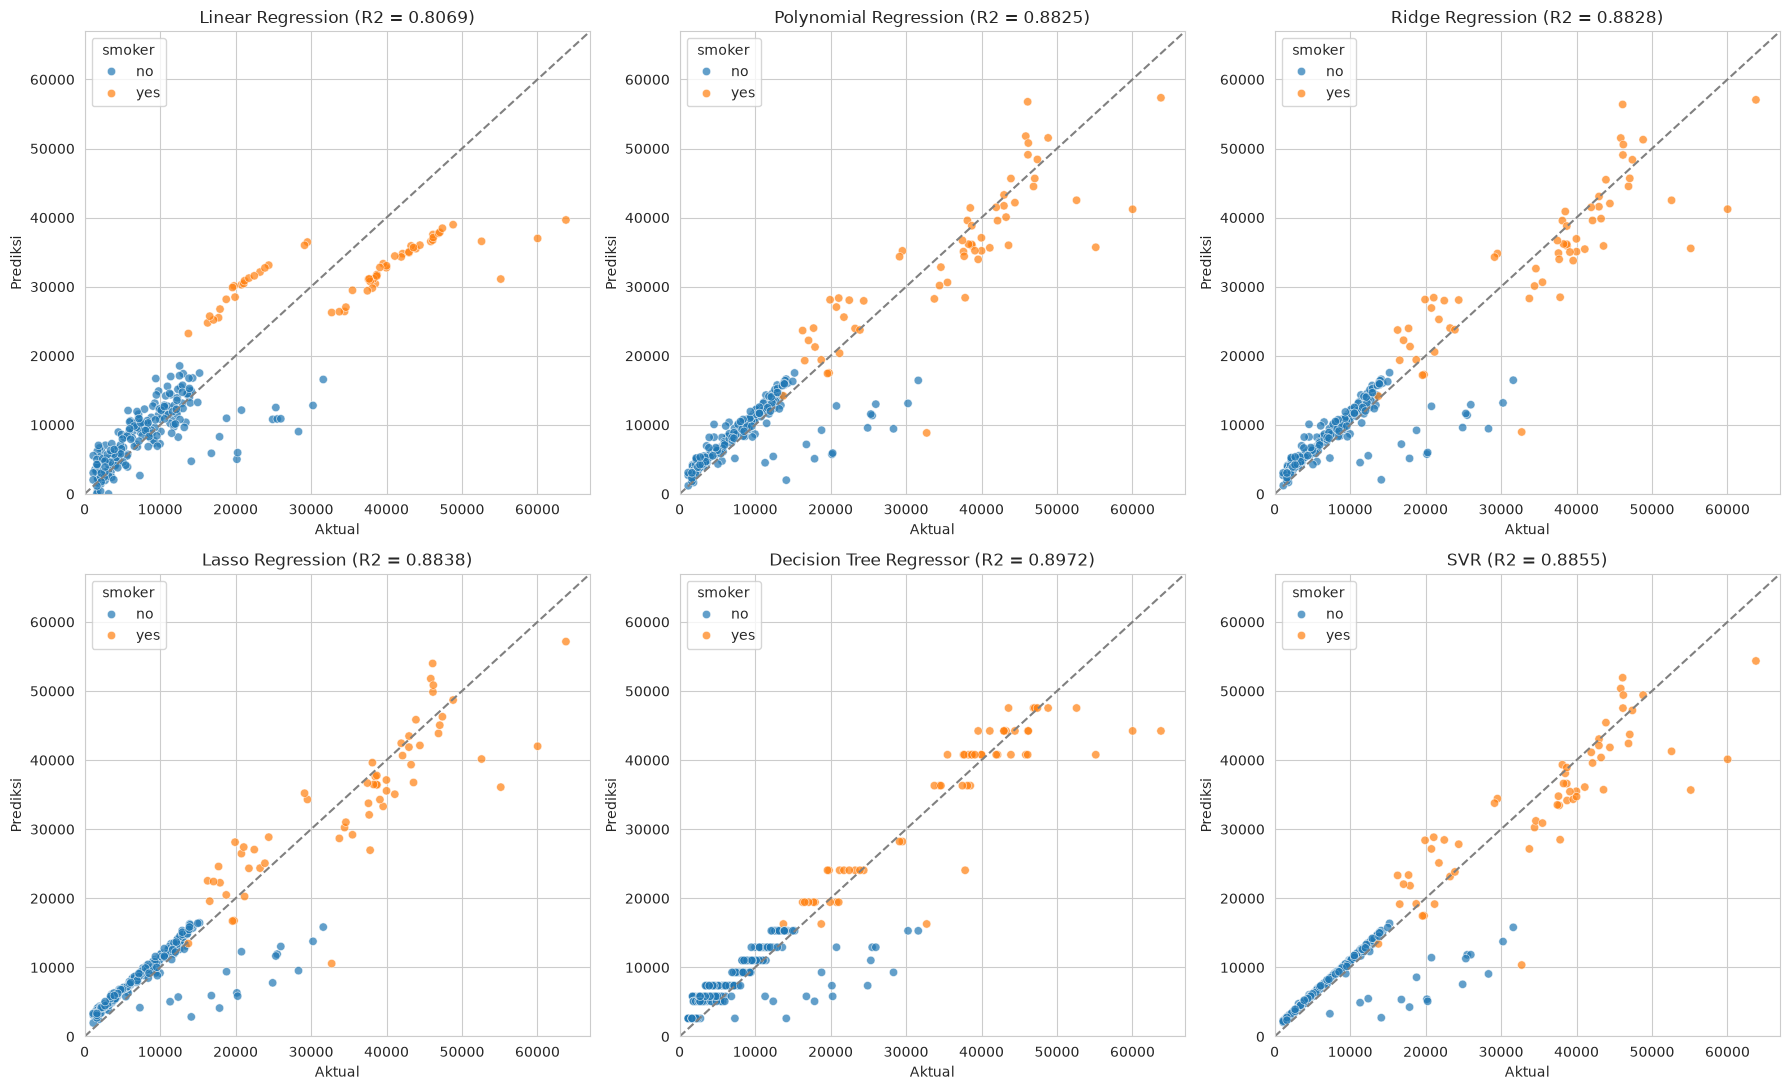

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
lim = [0, y_test.max() * 1.05]
for ax, (name, (model, pred)) in zip(axes.flatten(), models.items()):
    sns.scatterplot(x=y_test, y=pred, hue=X_test['smoker'], hue_order=['no', 'yes'], ax=ax, alpha=0.7)
    ax.plot(lim, lim, linestyle='--', color='gray')
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_title(f"{name} (R2 = {r2_score(y_test, pred):.4f})")
    ax.set_xlabel('Aktual')
    ax.set_ylabel('Prediksi')

plt.tight_layout()
plt.show()

Pada Linear Regression titik-titik perokok tersebar jauh dari garis diagonal, karena model tidak dapat menangkap lonjakan biaya pada perokok dengan BMI tinggi. Model lain sudah lebih rapat ke diagonal. Sisa error terbesar pada semua model berasal dari sekelompok kecil non-perokok dengan `charges` jauh di atas pita utama, yang kemungkinan dipengaruhi faktor yang tidak ada di dataset (misalnya riwayat penyakit).

# 5. Analisis

#### Bandingkan hasil Linear Regression, Polynomial Regression, Ridge, Lasso, Decision Tree Regressor, dan SVR berdasarkan metrik evaluasi. Jelaskan pengaruh preprocessing dan parameter yang digunakan terhadap hasil.


**Linear Regression** menjadi model terlemah (R² = 0,8069, RMSE = 5.956,34). Hubungan antara fitur dan `charges` tidak sepenuhnya linear karena adanya efek interaksi `bmi × smoker` dan pengaruh kuadratik `age`, sehingga model hanya mampu menangkap pola rata-rata.

**Polynomial Regression (degree 2)** menaikkan R² menjadi 0,8825 dan menurunkan MAE sekitar 31% (4.177 → 2.867), karena fitur interaksi berhasil merepresentasikan lonjakan biaya pada perokok obesitas. Degree yang lebih tinggi justru overfitting akibat jumlah fitur yang meledak (494 fitur pada degree 4 untuk 1069 sampel train).

**Ridge dan Lasso** dibangun di atas fitur polynomial degree 2. Hasil Ridge (R² = 0,8828) hampir identik dengan Polynomial biasa, karena dengan 44 fitur dan 1069 sampel model tersebut memang belum overfitting sehingga regularisasi L2 tidak banyak membantu. Lasso sedikit lebih baik (R² = 0,8838, RMSE = 4.620,46) dan lebih sederhana karena setengah koefisiennya bernilai nol. Scaling sangat penting pada kedua model ini, karena penalti alpha diterapkan sama rata ke seluruh koefisien sehingga fitur dengan skala berbeda akan dihukum secara tidak adil.

**Decision Tree Regressor** menjadi model terbaik berdasarkan RMSE dan R² (4.345,88 dan 0,8972). Struktur data ini cocok untuk tree: split pertama pada `smoker`, lalu `bmi` ≈ 30 dan `age` langsung memisahkan kelompok-kelompok biaya yang terlihat pada EDA. Pembatasan `max_depth = 4` dan `min_samples_leaf = 5` krusial, karena tanpa batas tree menghafal data train (Train R² = 1,0) dan Test R² turun ke 0,8194.

**SVR** memberikan MAE terendah (2.535,78) tetapi RMSE-nya sedikit di atas Decision Tree. Ini menunjukkan SVR sangat akurat untuk mayoritas data, namun kurang baik pada outlier, karena loss epsilon-insensitive bersifat linear (bukan kuadratik) terhadap error besar. SVR adalah model yang paling sensitif terhadap preprocessing: tanpa scaling target, R² bahkan bernilai negatif.

Secara keseluruhan, perbedaan antar 5 model non-linear relatif kecil (R² 0,8825–0,8972), sedangkan lompatan terbesar terjadi saat model diberi kemampuan menangkap interaksi `bmi × smoker`. Artinya, **representasi fitur lebih berpengaruh dibanding pemilihan algoritma** pada dataset ini.

# 6. Kesimpulan dan Saran

#### Berikan kesimpulan berdasarkan hasil eksperimen. Saran dapat berupa perubahan parameter, preprocessing, atau eksperimen lanjutan.


**Kesimpulan:**

1. `smoker` adalah faktor dominan biaya medis, diikuti `age` dan `bmi`. Interaksi `bmi × smoker` menjadi kunci peningkatan performa model.
2. **Decision Tree Regressor** (`max_depth=4`, `min_samples_leaf=5`) memberikan hasil terbaik dengan R² = 0,8972 dan RMSE = 4.345,88, sedangkan **SVR** memiliki MAE terendah (2.535,78).
3. Linear Regression biasa underfitting (R² = 0,8069) karena tidak bisa menangkap hubungan non-linear.
4. Preprocessing yang sesuai karakteristik model sangat berpengaruh: scaling wajib untuk Ridge, Lasso, dan SVR (bahkan target juga perlu di-scaling untuk SVR), sedangkan Decision Tree tidak memerlukannya.
5. Pemilihan hyperparameter (degree, alpha, max_depth, C/gamma) menggunakan cross validation berhasil menghindari overfitting yang terlihat jelas pada polynomial degree tinggi dan tree tanpa batas kedalaman.

**Saran:**

- Menambahkan fitur interaksi secara manual (misalnya `obese = bmi >= 30` dan `obese × smoker`) agar model linear sederhana dapat menyamai model non-linear dengan interpretasi yang lebih mudah.
- Mencoba transformasi log pada target `charges` untuk mengurangi pengaruh skewness.
- Mencoba model ensemble seperti Random Forest atau Gradient Boosting yang umumnya lebih stabil dibanding single Decision Tree.
- Menggunakan repeated cross validation untuk evaluasi akhir, karena hasil pada satu test split (268 sampel) cukup bergantung pada pembagian data, terlihat dari Train R² yang lebih rendah dibanding Test R².